In [292]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('darkgrid')

# **Data ingestion**

## Importing dataset

In [293]:
# Fonte. https://www.timeshighereducation.com/world-university-rankings/2024/world-ranking

df = pd.read_csv('THE World University Rankings 2016-2024.csv', encoding='cp1252')
df

,Rank,Name,Country,Student Population,Students to Staff Ratio,International Students,Female to Male Ratio,Overall Score,Teaching,Research Environment,Research Quality,Industry Impact,International Outlook,Year
0,1.0,California Institute of Technology,United States,2243,6.9,26%,33 : 67,95.2000,95.6,97.6,99.8,97.8,64.0,2016
1,2.0,University of Oxford,United Kingdom,19920,11.6,34%,46:54:00,94.2000,86.5,98.9,98.8,73.1,94.4,2016
2,3.0,Stanford University,United States,15596,7.8,22%,42:58:00,93.9000,92.5,96.2,99.9,63.3,76.3,2016
3,4.0,University of Cambridge,United Kingdom,18810,11.8,34%,46:54:00,92.8000,88.2,96.7,97.0,55.0,91.5,2016
4,5.0,Massachusetts Institute of Technology,United States,11074,9.0,33%,37 : 63,92.0000,89.4,88.6,99.7,95.4,84.0,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12425,1900.0,Penza State University,Russian Federation,17934,17.2,12%,56:44:00,12.1935,14.3,8.7,7.8,16.3,32.8,2024
12426,1901.0,Universidad Peruana de Ciencias Aplicadas (UPC),Peru,56595,21.1,1%,50:50:00,12.1470,13.5,8.7,10.1,15.6,26.5,2024
12427,1902.0,Universidade Federal Rural do Semi-Arido,Brazil,8687,12.4,0%,49:51:00,11.9910,19.1,9.0,5.7,16.6,18.3,2024
12428,1903.0,State University of Bahia,Brazil,25067,11.9,0%,66:34:00,11.5655,19.3,8.6,4.1,16.2,20.0,2024


## Overall information

In [294]:
df.dtypes

Rank                       float64
Name                        object
Country                     object
Student Population           int64
Students to Staff Ratio    float64
International Students      object
Female to Male Ratio        object
Overall Score              float64
Teaching                   float64
Research Environment       float64
Research Quality           float64
Industry Impact            float64
International Outlook      float64
Year                         int64
dtype: object

In [295]:
df.isna().sum()

Rank                         0
Name                         0
Country                      0
Student Population           0
Students to Staff Ratio      0
International Students       0
Female to Male Ratio       591
Overall Score                0
Teaching                     0
Research Environment         0
Research Quality             0
Industry Impact              0
International Outlook        0
Year                         0
dtype: int64

In [296]:
df.loc[(df['Female to Male Ratio'].isna()) & (df['Country'] == 'Italy')]

,Rank,Name,Country,Student Population,Students to Staff Ratio,International Students,Female to Male Ratio,Overall Score,Teaching,Research Environment,Research Quality,Industry Impact,International Outlook,Year
330,331.0,University of Naples Federico II,Italy,83653,64.2,1%,NaN,39.0075,24.7,14.8,81.3,47.4,21.1,2016
500,501.0,Università Cattolica del Sacro Cuore,Italy,30304,18.9,10%,NaN,29.4825,18.6,11.3,55.4,38.7,39.0,2016
1381,582.0,Università Cattolica del Sacro Cuore,Italy,30263,18.9,8%,NaN,28.5400,18.0,7.6,56.4,40.3,39.1,2017
2000,220.0,University of Bologna,Italy,62296,22.2,10%,NaN,50.6425,43.6,30.1,80.0,39.1,47.4,2018
2209,429.0,University of Turin,Italy,59116,31.4,7%,NaN,38.3700,20.6,20.3,72.3,45.3,43.7,2018
2358,578.0,Università Cattolica del Sacro Cuore,Italy,32844,11.4,8%,NaN,31.7075,19.7,11.6,62.5,35.3,35.8,2018
9028,302.0,Politecnico di Milano,Italy,37532,25.4,18%,NaN,48.7250,39.0,45.3,56.4,74.6,62.0,2023


# **Data Wrangling**

## 'Rank'
**Convering 'rank' column into int16**

In [297]:
# To avoid any misplaced value, the df is first sorted  by overall score 
# and then 'rank' value is assigned based on the position
df.sort_values(by='Overall Score', ascending=False, inplace=True)
df['Rank'] = np.arange(1, df.shape[0]+1, dtype='int16')

**Correlation between Rank and Overall Score**

(0.0, 100.0)

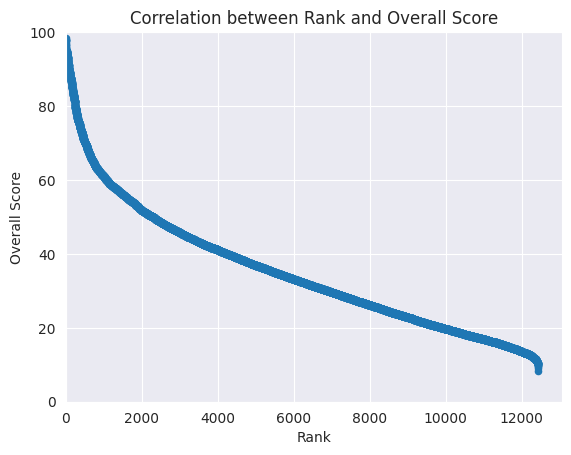

In [298]:
df.plot.scatter(x='Rank', y='Overall Score')

plt.title('Correlation between Rank and Overall Score')
plt.xlim(0)
plt.ylim([0, 100])

## 'International Students'
**Converting to float64**

In [299]:
"""
# Remove '%' symbol
df['International Students'] = df['International Students'].apply(lambda x : x.replace('%',  ''))
# If the resulting string is '', it is replaced with np.NaN 
df['International Students'] = df['International Students'].replace('', np.NaN)
# Fill all np.NaN with the previous value
df['International Students'] = df.groupby('Name')['International Students'].bfill()
# Value is converted to a float
df['International Students'] = df['International Students'].astype('float64').apply(lambda x : x / 100)
"""

"\n# Remove '%' symbol\ndf['International Students'] = df['International Students'].apply(lambda x : x.replace('%',  ''))\n# If the resulting string is '', it is replaced with np.NaN \ndf['International Students'] = df['International Students'].replace('', np.NaN)\n# Fill all np.NaN with the previous value\ndf['International Students'] = df.groupby('Name')['International Students'].bfill()\n# Value is converted to a float\ndf['International Students'] = df['International Students'].astype('float64').apply(lambda x : x / 100)\n"

In [300]:
# Remove '%' symbol
df['International Students'] = df['International Students'].apply(lambda x : x.replace('%',  ''))
# If the resulting string is '', it is replaced with np.NaN 
df['International Students'] = df['International Students'].replace('', np.NaN)
# Fill np.NaN
## ffille -> Use last valid value
## bfill -> Use next valid value
df['International Students'] = df.groupby('Name')['International Students'].ffill().bfill()
# Value is converted to a float
df['International Students'] = df['International Students'].astype('float64').apply(lambda x : x / 100)

**Plotting the graph**

(0.0, 1.0)

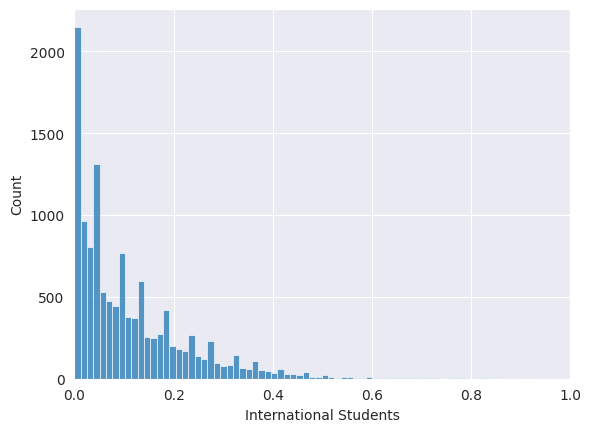

In [301]:
sns.histplot(
    x = 'International Students',
    data = df
)

plt.xlim([0, 1])

# 'Female To Male Ratio'

**Converting to float64**

In [302]:
def female_to_male_wrangling(x):
    try:
        return float(x)
    except ValueError:
        float(x[:x.find(':')]) / 100


df['Female to Male Ratio'] = df['Female to Male Ratio'].apply(female_to_male_wrangling)


**Filling missing value**

In [303]:
df['Female to Male Ratio'] = df['Female to Male Ratio'].ffill().bfill()

**Plotting the graph**

(0.0, 1.0)

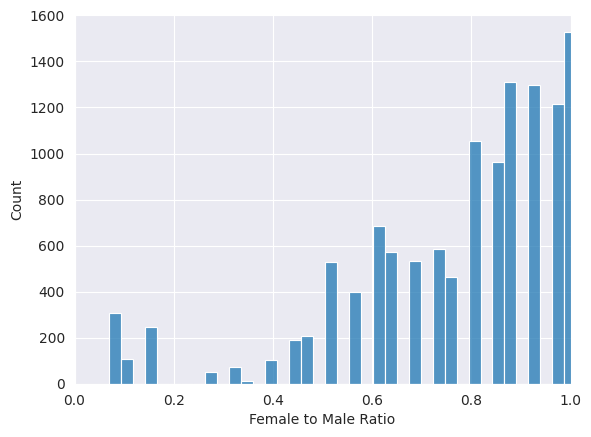

In [304]:
sns.histplot(
    x = 'Female to Male Ratio',
    data = df
)

plt.xlim([0, 1])

# **Data analysis**

In [305]:
df.dtypes

Rank                         int16
Name                        object
Country                     object
Student Population           int64
Students to Staff Ratio    float64
International Students     float64
Female to Male Ratio       float64
Overall Score              float64
Teaching                   float64
Research Environment       float64
Research Quality           float64
Industry Impact            float64
International Outlook      float64
Year                         int64
dtype: object

In [306]:
df.isna().sum()

Rank                       0
Name                       0
Country                    0
Student Population         0
Students to Staff Ratio    0
International Students     0
Female to Male Ratio       0
Overall Score              0
Teaching                   0
Research Environment       0
Research Quality           0
Industry Impact            0
International Outlook      0
Year                       0
dtype: int64

In [307]:
df_2024 = df.loc[df['Year'] == 2024].copy()
df_2024['Rank'] = np.arange(1, df_2024.shape[0]+1)
df_2024

,Rank,Name,Country,Student Population,Students to Staff Ratio,International Students,Female to Male Ratio,Overall Score,Teaching,Research Environment,Research Quality,Industry Impact,International Outlook,Year
10526,1,University of Oxford,United Kingdom,21750,10.9,0.42,0.929861,98.4575,96.6,100.0,99.0,98.7,97.5,2024
10527,2,Stanford University,United States,14517,6.4,0.23,0.929861,97.9720,99.0,97.8,99.6,100.0,87.0,2024
10528,3,Massachusetts Institute of Technology,United States,11085,8.0,0.33,0.929861,97.9300,98.6,96.2,99.7,100.0,93.8,2024
10529,4,Harvard University,United States,20050,9.0,0.25,0.929861,97.7905,97.7,99.9,99.4,84.2,90.8,2024
10530,5,University of Cambridge,United Kingdom,20565,11.5,0.38,0.929861,97.4820,95.8,100.0,98.0,87.9,97.4,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12425,1900,Penza State University,Russian Federation,17934,17.2,0.12,0.684028,12.1935,14.3,8.7,7.8,16.3,32.8,2024
12426,1901,Universidad Peruana de Ciencias Aplicadas (UPC),Peru,56595,21.1,0.01,0.684028,12.1470,13.5,8.7,10.1,15.6,26.5,2024
12427,1902,Universidade Federal Rural do Semi-Arido,Brazil,8687,12.4,0.00,0.684028,11.9910,19.1,9.0,5.7,16.6,18.3,2024
12428,1903,State University of Bahia,Brazil,25067,11.9,0.00,0.479167,11.5655,19.3,8.6,4.1,16.2,20.0,2024


In [308]:
df_2024.loc[df['Country'] == 'Italy']

,Rank,Name,Country,Student Population,Students to Staff Ratio,International Students,Female to Male Ratio,Overall Score,Teaching,Research Environment,Research Quality,Industry Impact,International Outlook,Year
10681,156,University of Bologna,Italy,74105,24.7,0.11,0.888889,61.7675,53.0,44.6,86.5,79.4,54.3,2024
10696,171,Scuola Normale Superiore di Pisa,Italy,614,7.4,0.11,0.929861,60.7970,60.1,42.6,82.9,34.9,59.3,2024
10706,181,Sapienza University of Rome,Italy,60522,22.2,0.09,0.929861,60.0050,53.5,48.1,77.9,85.4,46.5,2024
10732,207,Sant’Anna School of Advanced Studies – Pisa,Italy,718,7.4,0.20,0.806944,58.3800,50.4,39.0,80.1,90.3,60.8,2024
10751,226,Politecnico di Milano,Italy,38978,25.7,0.19,1.011806,57.3480,42.9,49.7,71.9,95.3,65.3,2024
10753,228,University of Padua,Italy,44401,26.5,0.07,0.970833,57.0610,46.1,38.5,84.1,77.1,53.1,2024
10799,274,Humanitas University,Italy,1988,17.9,0.18,0.929861,54.5640,32.3,27.9,98.0,62.8,67.1,2024
10813,288,Vita-Salute San Raffaele University,Italy,4087,13.9,0.05,0.929861,53.9050,34.6,26.9,98.3,66.8,49.8,2024
10835,310,Università Cattolica del Sacro Cuore,Italy,28830,39.1,0.07,0.888889,52.8065,35.2,30.0,89.4,74.5,52.3,2024
10846,321,University of Pavia,Italy,17701,31.5,0.09,0.151389,52.2650,37.6,32.3,82.7,80.4,50.4,2024
